In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os.path as op

from specula.mmlib.compute_rec import rec_phot_cov, rec_ron_cov
from specula.mmlib.utils import get_pupil_mask, radial_order
from specula.mmlib.analyse_data import get_sim_data, get_psd

root_dir = '/raid1/mmenessini/calibration/RISTRETTOunobs'

2026-06-22 11:50:05,940 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-22 11:50:06,063 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

In [3]:
rMods = np.array([0,1,2,3])
n_subaps = np.array([12,16,24,48]) #np.array([16,24,48])
n_modes = np.array([50,150,300,600,1200]) #np.array([150,300,1300])
seeings = np.array([0.5,0.7,0.9,1.1,1.3,1.5]) #np.array([0.7,0.9,1.1])

In [4]:
def generate_psd(f, cutoff, power):
    f_safe = np.maximum(f, f[0])
    psd_turb = np.where(f_safe <= cutoff, 1.0, (f_safe / cutoff)**(-17/3))
    df = np.gradient(f)
    # f_s = f[-1] * 2 
    # sinc_filter = np.sinc(f_safe / f_s)**2 
    # psd_turb *= sinc_filter
    psd_turb *= (power / np.sum(psd_turb * df))
    return psd_turb

Text(0.5, 1.0, '1.5" seeing, 1200 modes corrected\n48x48 pyWFS, RON=0.5e-, flux=1.0e+06')

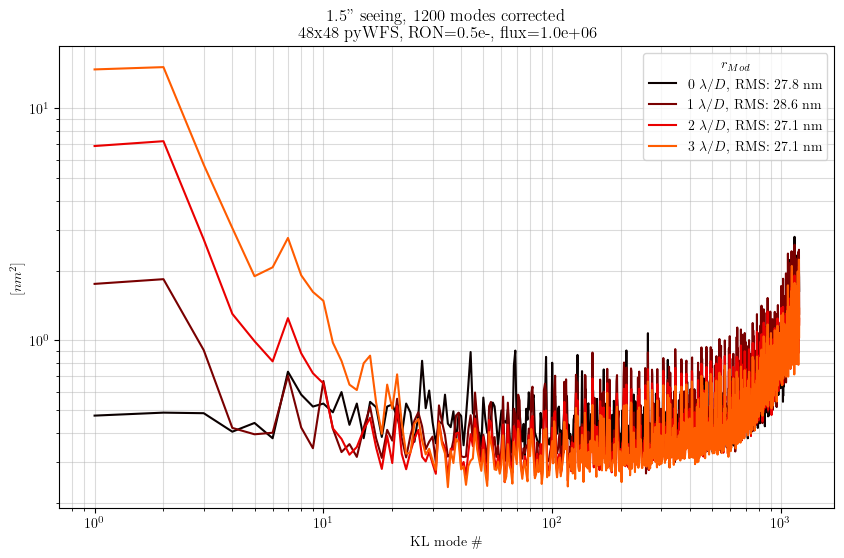

In [56]:
def get_rec_covariance(rMod,n_subap,seeing,Nphot,RON,res:str='',doplot:bool=False):

    pyr_mask = get_pupil_mask(npix=120,filepath=op.join(root_dir,'pupils',f'pyr_pupdata_{n_subap:.0f}x{n_subap:.0f}.fits'))
    frame = fits.getdata(op.join(root_dir,'frames',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_avg_frame.fits'))
    sn = fits.getdata(op.join(root_dir,'slopenulls',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_sn.fits'))+2e-2
    alias = fits.getdata(op.join(root_dir,'aliasing',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_alias.fits'))
    rec = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_{N}modes_rec.fits'))
    simpc = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes{res}_simpc.fits'))

    og = np.diag(rec @ simpc)
    ct = np.sqrt(np.sum((rec @ simpc)**2,axis=0)-og**2)

    ron_cov = rec_ron_cov(rec,frame,mask=pyr_mask)*RON/Nphot**2 
    shot_cov = rec_phot_cov(rec,frame,mask=pyr_mask,sn=sn)/Nphot
    cov = ron_cov + shot_cov

    if doplot:
        x = np.arange(N)+1
        plt.figure()
        plt.loglog(x,ron_cov)
        plt.loglog(x,shot_cov)
        plt.loglog(x,cov)
        plt.grid()

    return cov,og,ct,alias


n_subap = 48
seeing = 1.5
N = 1200
RON = 0.5
Nphot = 1e+6

res = '_1Nm' #'' #
cov0,og0,ct0,alias0 = get_rec_covariance(rMod=0,n_subap=n_subap,seeing=seeing,Nphot=Nphot,RON=RON,res=res)
cov1,og1,ct1,alias1 = get_rec_covariance(rMod=1,n_subap=n_subap,seeing=seeing,Nphot=Nphot,RON=RON,res=res)
cov2,og2,ct2,alias2 = get_rec_covariance(rMod=2,n_subap=n_subap,seeing=seeing,Nphot=Nphot,RON=RON,res=res)
cov3,og3,ct3,alias3 = get_rec_covariance(rMod=3,n_subap=n_subap,seeing=seeing,Nphot=Nphot,RON=RON,res=res)

coverr = lambda cov,alias,og: (cov+alias**2)/og**2

err0 = coverr(cov0,alias0,og0)
err1 = coverr(cov1,alias1,og1)
err2 = coverr(cov2,alias2,og2)
err3 = coverr(cov3,alias3,og3)

x = np.arange(N)+1
plt.figure(figsize=(10,6))
plt.loglog(x,err0,label=r'0 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err0)):1.1f} nm')
plt.loglog(x,err1,label=r'1 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err1)):1.1f} nm')
plt.loglog(x,err2,label=r'2 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err2)):1.1f} nm')
plt.loglog(x,err3,label=r'3 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err3)):1.1f} nm')
plt.grid(which='both',alpha=0.45)
plt.legend(loc='best',title='$r_{Mod}$')
plt.xlabel(r'KL mode \#')
plt.ylabel('[$nm^2$]')
plt.title(f'{seeing:1.1f}" seeing, {N} modes corrected\n{n_subap}x{n_subap} pyWFS, RON={RON:1.1f}e-, flux={Nphot:1.1e}')

Using data directory: /raid1/mmenessini/results/RISTRETTOunobs/20260621_105343
key: coro_psf_std type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: coro_psf_int type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_meas type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
0.9643890968875763 0.005672489303138831 0.0058007943 0.9644321


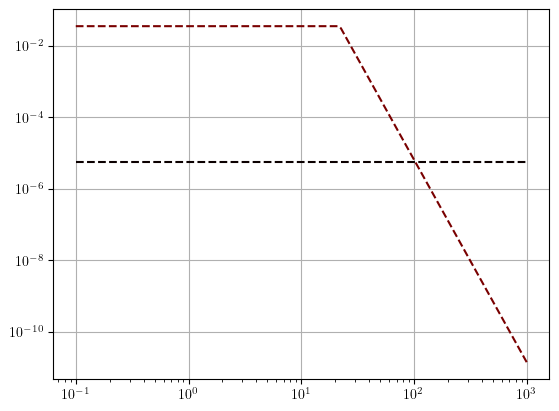

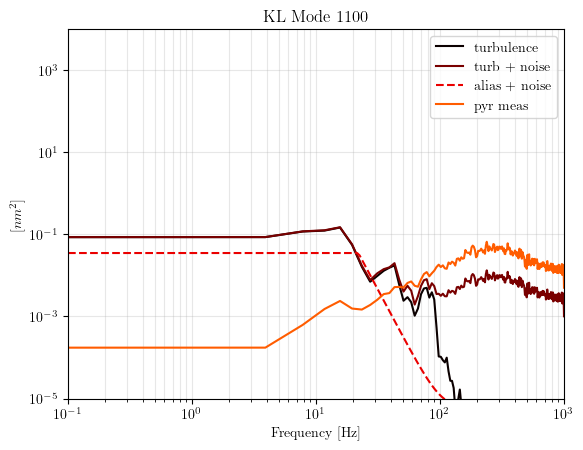

In [65]:
datadict = get_sim_data(root_dir='/raid1/mmenessini/results/RISTRETTOunobs')


VoverD = 12/8.2
cutoff = 0.3*(radial_order(N)+1+1)*VoverD

idx = 1100
ct_amp = 1e-9
ff = np.logspace(-1,3,200)
alias_psd = generate_psd(ff,cutoff,power=alias0[idx]**2)
noise_psd = np.ones_like(ff)
noise_psd *= (cov0[idx]+ct0[idx]*ct_amp)/(np.sum(noise_psd * np.gradient(ff)))

plt.figure()
plt.loglog(ff,noise_psd,'--')
plt.loglog(ff,alias_psd,'--')
plt.grid()

print(np.sqrt(np.trapezoid(alias_psd,ff)),np.trapezoid(noise_psd,ff),cov0[idx],alias0[idx])

N = 1200
pol = datadict['dm_cmd'][1:] + datadict['pyr_meas'][:-1]
ol = datadict['dm_cmd'] + datadict['dm_res'][:,:N]

init = 100
res_psd,f = get_psd(datadict['dm_res'][init:].T,dt=0.0005,nperseg=512)
pyr_psd,f = get_psd(datadict['pyr_meas'][init:].T,dt=0.0005,nperseg=512)
ol_psd,f = get_psd(ol[init:].T,dt=0.0005,nperseg=512)
pol_psd,f = get_psd(pol[init-1:].T,dt=0.0005,nperseg=512)
atmo_psd,f = get_psd(datadict['atmo_res'][init:].T,dt=0.0005,nperseg=512)

plt.figure()
plt.loglog(f,atmo_psd[idx],label='turbulence')
plt.loglog(f,ol_psd[idx],label='turb + noise')
plt.loglog(ff,noise_psd+alias_psd,'--',label='alias + noise')
# plt.loglog(f,pol_psd[idx])
plt.loglog(f,pyr_psd[idx],label='pyr meas')
# plt.loglog(f,res_psd[idx],label='residual')
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'[$nm^2$]')
plt.title(f'KL Mode {idx}')
plt.ylim([1e-5,1e+4])
plt.xlim([0.1,1e+3])
plt.grid(which='both',alpha=0.3)